# Chest X-Ray Pneumonia Training

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import tensorflow as tf

In [2]:
# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
INITIAL_EPOCHS = 8
FINE_TUNE_EPOCHS = 6
BASE_LR = 1e-4
FINE_TUNE_LR = 1e-5
DATA_DIR = Path("chest_xray")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUTPUT_DIR.resolve())

Data dir: F:\11'th semester Lab\Ai Project\CHEST X-RAY PNEUMONIA02\chest_xray
Output dir: F:\11'th semester Lab\Ai Project\CHEST X-RAY PNEUMONIA02\outputs


In [3]:
def build_datasets(data_dir: Path):
    train_dir = data_dir / "train"
    val_dir = data_dir / "val"
    test_dir = data_dir / "test"

    class_names = sorted([item.name for item in train_dir.iterdir() if item.is_dir()])
    class_counts = {class_name: count_class_images(train_dir / class_name) for class_name in class_names}
    target_count = max(class_counts.values())

    balanced_train_ds = None
    for index, class_name in enumerate(class_names):
        class_ds = make_class_dataset(train_dir, class_name, float(index), target_count)
        balanced_train_ds = class_ds if balanced_train_ds is None else balanced_train_ds.concatenate(class_ds)

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        labels="inferred",
        label_mode="binary",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        labels="inferred",
        label_mode="binary",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    autotune = tf.data.AUTOTUNE
    train_ds = balanced_train_ds.shuffle(target_count * len(class_names), seed=SEED, reshuffle_each_iteration=True)
    train_ds = train_ds.batch(BATCH_SIZE).prefetch(buffer_size=autotune)
    val_ds = val_ds.cache().prefetch(buffer_size=autotune)
    test_ds = test_ds.cache().prefetch(buffer_size=autotune)

    return train_ds, val_ds, test_ds, class_names, class_counts

In [4]:
def compile_model(model, learning_rate: float):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )


def count_class_images(class_dir: Path):
    return sum(1 for item in class_dir.iterdir() if item.is_file())


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)


def make_class_dataset(train_dir: Path, class_name: str, label: float, target_count: int):
    file_paths = sorted([item for item in (train_dir / class_name).iterdir() if item.is_file()])
    path_ds = tf.data.Dataset.from_tensor_slices([str(path) for path in file_paths])
    path_ds = path_ds.shuffle(len(file_paths), seed=SEED, reshuffle_each_iteration=True).repeat()
    label_ds = tf.data.Dataset.from_tensors(tf.cast(label, tf.float32)).repeat()
    ds = tf.data.Dataset.zip((path_ds, label_ds))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.take(target_count)


def merge_histories(*histories):
    combined_history = {}
    for history in histories:
        for key, values in history.history.items():
            combined_history.setdefault(key, []).extend([float(value) for value in values])
    return combined_history


def collect_labels(dataset):
    label_batches = []
    for _, batch_labels in dataset:
        label_batches.append(tf.reshape(batch_labels, [-1]))
    return tf.cast(tf.concat(label_batches, axis=0), tf.float32).numpy().astype(np.int32)


def find_best_threshold(y_true, y_prob):
    best_threshold = 0.5
    best_accuracy = -1.0
    for threshold in np.linspace(0.2, 0.8, 121):
        y_pred = (y_prob >= threshold).astype(np.int32)
        accuracy = float((y_pred == y_true).mean())
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = float(threshold)
    return best_threshold, best_accuracy


def save_json(path: Path, payload):
    with open(path, "w", encoding="utf-8") as file_handle:
        json.dump(payload, file_handle, indent=2)

In [5]:
def build_model():
    data_augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.04),
            tf.keras.layers.RandomTranslation(0.04, 0.04),
            tf.keras.layers.RandomZoom(0.12),
            tf.keras.layers.RandomContrast(0.1),
        ],
        name="augmentation",
    )

    inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.densenet.preprocess_input(x)

    base_model = tf.keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs, name="chest_xray_densenet121")
    compile_model(model, BASE_LR)

    return model, base_model

In [6]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")

train_ds, val_ds, test_ds, class_names, class_counts = build_datasets(DATA_DIR)
model, base_model = build_model()

print("Classes:", class_names)
print("Class counts:", class_counts)
print("Training set is balanced by oversampling the minority class to match the majority count.")
model.summary()

Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']
Class counts: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Training set is balanced by oversampling the minority class to match the majority count.


Model: "chest_xray_densenet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,304,257 (27.86 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(OUTPUT_DIR / "best_model.keras"),
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

stage1_callbacks = [
    checkpoint,
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=stage1_callbacks,
    verbose=1,
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

compile_model(model, FINE_TUNE_LR)

stage2_callbacks = [
    checkpoint,
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=2,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=len(history_stage1.history["loss"]),
    epochs=len(history_stage1.history["loss"]) + FINE_TUNE_EPOCHS,
    callbacks=stage2_callbacks,
    verbose=1,
)

history = merge_histories(history_stage1, history_stage2)

Epoch 1/8
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.7919 - auc: 0.8629 - loss: 0.4372 - precision: 0.7985 - recall: 0.8035
Epoch 1: val_auc improved from None to 0.89062, saving model to outputs\best_model.keras

Epoch 1: finished saving model to outputs\best_model.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 253s 930ms/step - accuracy: 0.8646 - auc: 0.9405 - loss: 0.3114 - precision: 0.8627 - recall: 0.8674 - val_accuracy: 0.9375 - val_auc: 0.8906 - val_loss: 0.3180 - val_precision: 1.0000 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 2/8
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.9221 - auc: 0.9758 - loss: 0.1975 - precision: 0.9287 - recall: 0.9139
Epoch 2: val_auc improved from 0.89062 to 0.96875, saving model to outputs\best_model.keras

Epoch 2: finished saving model to outputs\best_model.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 231s 914ms/step - accuracy: 0.9255 - auc: 0.9789 - loss: 0.1848 - precision: 0.9324 - recall: 0.9177 - val_accuracy: 0.8750 - val_a

In [ ]:
val_probs = model.predict(val_ds, verbose=0).ravel()
val_labels = collect_labels(val_ds)
best_threshold, val_accuracy = find_best_threshold(val_labels, val_probs)

save_json(OUTPUT_DIR / "decision_threshold.json", {
    "best_threshold": best_threshold,
    "val_accuracy_at_threshold": val_accuracy,
})

print("Best validation threshold:", best_threshold)
print("Validation accuracy at threshold:", val_accuracy)

Best validation threshold: 0.2
Validation accuracy at threshold: 0.9375


In [ ]:
# Evaluate model
# Rebuild datasets if needed (e.g., after kernel restart).
if "test_ds" not in globals():
    train_ds, val_ds, test_ds, class_names, class_counts = build_datasets(DATA_DIR)

if "best_threshold" not in globals():
    threshold_path = OUTPUT_DIR / "decision_threshold.json"
    if threshold_path.exists():
        with open(threshold_path, "r", encoding="utf-8") as file_handle:
            best_threshold = float(json.load(file_handle)["best_threshold"])
    else:
        best_threshold = 0.5

raw_test_metrics = model.evaluate(test_ds, verbose=1, return_dict=True)
test_probs = model.predict(test_ds, verbose=0).ravel()
test_labels = collect_labels(test_ds)
test_predictions = (test_probs >= best_threshold).astype(np.int32)

thresholded_accuracy = float((test_predictions == test_labels).mean())
true_positive = int(((test_predictions == 1) & (test_labels == 1)).sum())
false_positive = int(((test_predictions == 1) & (test_labels == 0)).sum())
false_negative = int(((test_predictions == 0) & (test_labels == 1)).sum())

thresholded_precision = true_positive / (true_positive + false_positive + 1e-7)
thresholded_recall = true_positive / (true_positive + false_negative + 1e-7)

test_metrics = {key: float(value) for key, value in raw_test_metrics.items()}
test_metrics.update({
    "best_threshold": best_threshold,
    "thresholded_accuracy": thresholded_accuracy,
    "thresholded_precision": float(thresholded_precision),
    "thresholded_recall": float(thresholded_recall),
})

print("Test metrics:", test_metrics)
print("Thresholded accuracy:", thresholded_accuracy)
print("Best threshold:", best_threshold)

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 843ms/step - accuracy: 0.8958 - auc: 0.9568 - loss: 0.2790 - precision: 0.8842 - recall: 0.9590
Test metrics: {'accuracy': 0.8958333134651184, 'auc': 0.9568320512771606, 'loss': 0.2789662480354309, 'precision': 0.8841607570648193, 'recall': 0.9589743614196777, 'best_threshold': 0.2, 'thresholded_accuracy': 0.8397435897435898, 'thresholded_precision': 0.8072033896594908, 'thresholded_recall': 0.9769230766725838}
Thresholded accuracy: 0.8397435897435898
Best threshold: 0.2


In [ ]:
# Rebuild test data.
if "test_ds" not in globals():
    train_ds, val_ds, test_ds, class_names, class_counts = build_datasets(DATA_DIR)

if "best_threshold" not in globals():
    threshold_path = OUTPUT_DIR / "decision_threshold.json"
    if threshold_path.exists():
        with open(threshold_path, "r", encoding="utf-8") as file_handle:
            best_threshold = float(json.load(file_handle)["best_threshold"])
    else:
        best_threshold = 0.5

test_results = model.evaluate(test_ds, verbose=1, return_dict=True)
test_probs = model.predict(test_ds, verbose=0).ravel()
test_labels = collect_labels(test_ds)
test_predictions = (test_probs >= best_threshold).astype(np.int32)

thresholded_accuracy = float((test_predictions == test_labels).mean())
true_positive = int(((test_predictions == 1) & (test_labels == 1)).sum())
false_positive = int(((test_predictions == 1) & (test_labels == 0)).sum())
false_negative = int(((test_predictions == 0) & (test_labels == 1)).sum())

test_metrics = {key: float(value) for key, value in test_results.items()}
test_metrics.update({
    "best_threshold": best_threshold,
    "thresholded_accuracy": thresholded_accuracy,
    "thresholded_precision": true_positive / (true_positive + false_positive + 1e-7),
    "thresholded_recall": true_positive / (true_positive + false_negative + 1e-7),
})

model.save(OUTPUT_DIR / "final_model.keras")

save_json(OUTPUT_DIR / "class_names.json", class_names)
save_json(OUTPUT_DIR / "history.json", history)
save_json(OUTPUT_DIR / "test_metrics.json", test_metrics)

print("Training complete.")
print("Test metrics:", test_metrics)
print("Saved artifacts in:", OUTPUT_DIR.resolve())

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 818ms/step - accuracy: 0.8958 - auc: 0.9568 - loss: 0.2790 - precision: 0.8842 - recall: 0.9590
Training complete.
Test metrics: {'accuracy': 0.8958333134651184, 'auc': 0.9568320512771606, 'loss': 0.2789662480354309, 'precision': 0.8841607570648193, 'recall': 0.9589743614196777, 'best_threshold': 0.2, 'thresholded_accuracy': 0.8397435897435898, 'thresholded_precision': 0.8072033896594908, 'thresholded_recall': 0.9769230766725838}
Saved artifacts in: F:\11'th semester Lab\Ai Project\CHEST X-RAY PNEUMONIA02\outputs


## Single Image Test

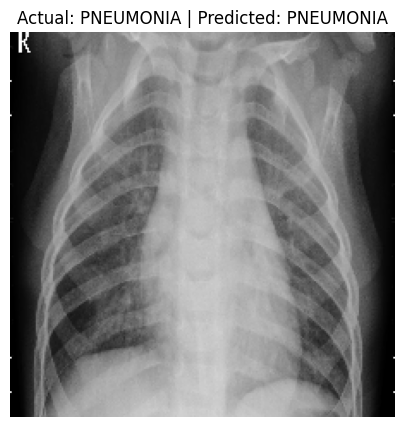

Prediction Score: 0.9642470479011536
Best threshold: 0.2
Using test_dir: chest_xray\test


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Load saved model if the in-memory model is unavailable (e.g., after kernel restart).
if "model" not in globals():
    model_path = OUTPUT_DIR / "best_model.keras"
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}. Run training first.")
    model = tf.keras.models.load_model(model_path)

if "best_threshold" not in globals():
    threshold_path = OUTPUT_DIR / "decision_threshold.json"
    if threshold_path.exists():
        with open(threshold_path, "r", encoding="utf-8") as file_handle:
            best_threshold = float(json.load(file_handle)["best_threshold"])
    else:
        best_threshold = 0.5

# Prefer Kaggle path if available; otherwise use local dataset path.
kaggle_test_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test"
local_test_dir = str(DATA_DIR / "test")
test_dir = kaggle_test_dir if os.path.exists(kaggle_test_dir) else local_test_dir

if not os.path.exists(test_dir):
    raise FileNotFoundError(f"Test directory not found: {test_dir}")

# Randomly choose class and image.
class_name = random.choice(["NORMAL", "PNEUMONIA"])
class_path = os.path.join(test_dir, class_name)
img_list = sorted(os.listdir(class_path))

if not img_list:
    raise RuntimeError(f"No images found in: {class_path}")

img_name = random.choice(img_list)
img_path = os.path.join(class_path, img_name)

# Load and preprocess to match the model pipeline.
img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict.
prediction = model.predict(img_array, verbose=0)
score = float(prediction[0][0])
pred_label = "PNEUMONIA" if score >= best_threshold else "NORMAL"

# Show image and result.
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Actual: {class_name} | Predicted: {pred_label}")
plt.axis("off")
plt.show()

print("Prediction Score:", score)
print("Best threshold:", best_threshold)
print("Using test_dir:", test_dir)